In [251]:
import keras

from keras.models import Sequential
from keras.layers import Input, Dense, Flatten
from keras.datasets import mnist
from keras.src.backend import shape
from keras.utils import to_categorical

from keras import layers
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from tensorflow.tools.docs.doc_controls import header

In [252]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

df = pd.read_csv(url, sep=",", header=None)
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.8,2.6,4.0,1.2,Iris-versicolor
1,5.5,2.6,4.4,1.2,Iris-versicolor
2,5.4,3.4,1.7,0.2,Iris-setosa
3,5.0,3.2,1.2,0.2,Iris-setosa
4,5.4,3.7,1.5,0.2,Iris-setosa


In [253]:
X = df.drop("class", axis=1)
y = pd.get_dummies(df["class"])

In [254]:
inputs = keras.Input(shape=(4,))
x = layers.Dense(128, activation="relu")(inputs)
outputs = layers.Dense(3, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="iris_model")

In [255]:
model.summary()

Model: "iris_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_27 (InputLayer)     │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,027 (4.01 KB)

 Trainable params: 1,027 (4.01 KB)

 Non-trainable params: 0 (0.00 B)

In [256]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

In [257]:
history = model.fit(X, y, batch_size=8, epochs=30, validation_split=0.2)

Epoch 1/30


I0000 00:00:1774016415.790338   21801 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_79039__.16


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.5000 - loss: 1.0097 - val_accuracy: 0.6667 - val_loss: 0.8847
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6667 - loss: 0.8352 - val_accuracy: 0.6667 - val_loss: 0.7665
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7083 - loss: 0.7180 - val_accuracy: 0.7333 - val_loss: 0.6862
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8750 - loss: 0.6448 - val_accuracy: 0.7333 - val_loss: 0.6286
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7250 - loss: 0.5887 - val_accuracy: 0.7333 - val_loss: 0.5859
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8250 - loss: 0.5448 - val_accuracy: 0.7333 - val_loss: 0.5491
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9083 - loss: 0.5116 - val_accuracy: 0.8667 - val_loss: 0.5201
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8333 - loss: 0.4800 - val_accuracy: 0.8667 - val_loss: 0.4960
Ep

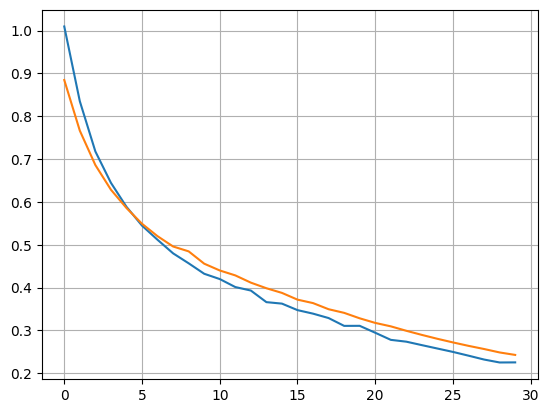

In [258]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.grid()
plt.show()

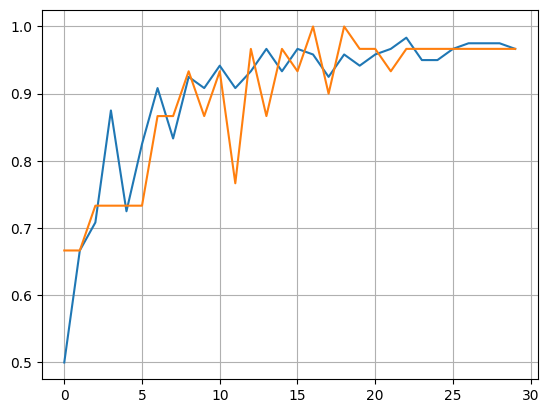

In [259]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.grid()
plt.show()

In [260]:
print(history.history["accuracy"][-1])
print(history.history["val_accuracy"][-1])

0.9666666388511658
0.9666666388511658
